### NOTE:
#### This notebook was designed for a different computing environment, and there may be many things to change i.e. file paths.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
import sys
sys.path.append(".")  # Add current directory to Python path
import utils
from datetime import datetime, timedelta
import calendar  # Smoothed line
from scipy.ndimage import gaussian_filter

## Functions that allow you to add a metric, in this case difference between msl minimum, to a dataframe of metrics. 

In [ ]:
def add_min_msl_diff_column(metrics_df, checkpoint_fp, era_truth_xr, variable, event_name, date = None):
    """
    Adds a column to metrics_df with them difference in variable minimum. This same type of function can be adopted to add other metrics.
    """

    print(f"Processing min MSL")
    reference_forecast = False
    # Check if the checkpoint file path contains "boring" to set the reference_forecast flag
    if "reference" in checkpoint_fp.lower():
        reference_forecast = True

    # Load the ERA5 truth data for the specific variable and time
    era_truth = trim_domain(era_truth_xr, event_name)

    # Get sorted checkpoint files
    checkpoint_files = get_sorted_checkpoint_files(checkpoint_fp) 

    if not checkpoint_files:
        print(f"No checkpoint files found in {checkpoint_fp}. Aborting calculation.")
        return metrics_df # Return original df if no files

    temp_minmax_dict = {} # Use a dictionary to store 
    first_file_processed_flag = True # Flag to check only the first file

    for checkpoint_num, filename in checkpoint_files:
        file_path = os.path.join(checkpoint_fp, filename)
        
        one_checkpoint = xr.open_dataset(file_path)[variable]
        one_checkpoint = trim_domain(one_checkpoint, event_name)
        
        temp_minmax_dict[checkpoint_num] = minmax_metric(one_checkpoint, era_truth, "min", dims=None)

    minmax_column_name = f"min_{variable}_{event_name}"
    if reference_forecast:
        minmax_column_name = f"reference_{date[:10]}"

    metrics_df[minmax_column_name] = metrics_df.index.map(temp_minmax_dict)
    
    print(f"Column '{minmax_column_name}' added/updated.")
    return metrics_df

def trim_domain(dataset, event_name):
    """
    Returns of the dataset trimmed to the domain of interest for the specified event. Can modify for different events.
    """
    if event_name == "Ian":
        lat_min, lat_max = 23, 32
        lon_min, lon_max = -89, -74
        if "lon" and "lat" in dataset.coords:
            return dataset.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min% 360, lon_max% 360))
        if "longitude" and "latitude" in dataset.coords:
            return dataset.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min% 360, lon_max% 360))

def get_sorted_checkpoint_files(checkpoint_fp):
    """
    Returns a sorted list of checkpoint files based on checkpoint numbers.
    """
    # Get a list of checkpoint files and extract checkpoint numbers
    checkpoint_files_with_numbers = []
    for filename in os.listdir(checkpoint_fp):
        if filename.startswith("Checkpoint"):
            match = re.search(r'Checkpoint(\d+)_', filename)
            if match:
                checkpoint_number = int(match.group(1))
                checkpoint_files_with_numbers.append((checkpoint_number, filename))
    # Sort the checkpoint files based on the checkpoint number
    checkpoint_files_with_numbers.sort(key=lambda x: x[0])
    return checkpoint_files_with_numbers

def minmax_metric(a, b, minmax_select, dims=None):
    """
    Compute difference between the minimum values in two xarray objects over all spatial dims (and time if present).
    Returns a single float if all dims are reduced.
    """
    # If dims not specified, use all dims in the data
    if dims is None:
        dims = list(a.dims)

    if minmax_select == "min":
        diff = float(np.min(a.values) - np.min(b.fields.values))
    elif minmax_select == "max":
        diff = float(np.max(a.values) - np.max(b.fields.values))    
    else:
        raise ValueError(f"Invalid minmax_select: {minmax_select}. Must be 'min' or 'max'.")
        
    return diff


## Make a pandas dataframe with reference and event metric

In [ ]:
event_name = "Ian"
event_date = "2022_09_24"

checkpoint_fp = "/projectnb/eb-general/wade/sfno/inference_runs/Ian/leadtime_fivedays/"
reference_checkpoint_fp = "/projectnb/eb-general/wade/sfno/inference_runs/Ian/Reference_fivedays/"
initialize_data_fp = "/projectnb/eb-general/wade/sfno/inference_runs/Ian/Initialize_data/"

# Initialize empty dataframe to store metrics
checkpoint_numbers = np.arange(1,91)
metrics_df = pd.DataFrame(index=checkpoint_numbers)
metrics_df.index.name = 'Checkpoint'  # Set the index name
metrics_df.sort_index(inplace=True)  # Sort by Checkpoint number

# list reference dates from reference_checkpoing_fp
dates = os.listdir(reference_checkpoint_fp)

dates.sort()
dates.append(event_date) # The last date is the event date
dates = [f"{d}T00_nsteps20" for d in dates] #reformat to match checkpoint file format
initial_dates = [datetime.strftime(datetime.strptime(d, "%Y_%m_%dT%H_nsteps20")-timedelta(days = 5), "%Y_%m_%dT%H_nsteps20") for d in dates] #create intiialize date list


In [171]:
# Ideall you run this once and save a csv with the results. Then load that csv next time.

for date in list(dates):
    print(date)
    if date != f"{event_date}T00_nsteps20":
        era_truth_xr = xr.open_dataset(f"{initialize_data_fp}Initialize_"+date+".nc").sel(variable="msl").isel(time=-1)

        metrics_df = add_min_msl_diff_column(metrics_df= metrics_df,
                                           checkpoint_fp=f"{reference_checkpoint_fp}{date[:10]}/", 
                                           era_truth_xr= era_truth_xr, 
                                           variable = "msl" , 
                                           event_name = event_name,
                                           date = date)
    else:
        era_truth_xr = xr.open_dataset(f"/barnes-engr-scratch2/C837824079/Experiment7/Initialize_data/Initialize_"+date+".nc").sel(variable="msl").isel(time=-1)
        metrics_df = add_min_msl_diff_column(metrics_df= metrics_df,
                                           checkpoint_fp=checkpoint_fp, 
                                           era_truth_xr= era_truth_xr, 
                                           variable = "msl" , 
                                           event_name = event_name)




2019_09_04T00_nsteps20
Processing min MSL
Column 'reference_2019_09_04' added/updated.
2019_09_17T00_nsteps20
Processing min MSL
Column 'reference_2019_09_17' added/updated.
2019_09_25T00_nsteps20
Processing min MSL
Column 'reference_2019_09_25' added/updated.
2021_09_13T00_nsteps20
Processing min MSL
Column 'reference_2021_09_13' added/updated.
2021_09_19T00_nsteps20
Processing min MSL
Column 'reference_2021_09_19' added/updated.
2021_09_21T00_nsteps20
Processing min MSL
Column 'reference_2021_09_21' added/updated.
2022_09_04T00_nsteps20
Processing min MSL
Column 'reference_2022_09_04' added/updated.
2022_09_17T00_nsteps20
Processing min MSL
Column 'reference_2022_09_17' added/updated.
2022_09_22T00_nsteps20
Processing min MSL
Column 'reference_2022_09_22' added/updated.
2022_09_25T00_nsteps20
Processing min MSL
Column 'reference_2022_09_25' added/updated.
2022_09_24T00_nsteps20
Processing min MSL
Column 'min_msl_Ian' added/updated.


In [152]:
metrics_df = np.abs(metrics_df) # absolute difference
metrics_df = metrics_df/ 100  # convert to hPa
metrics_df

# # save metrics 
# metrics_df.to_csv("min_msl_metric.csv")


,reference_2019_09_04,reference_2019_09_17,reference_2019_09_25,reference_2021_09_13,reference_2021_09_19,reference_2021_09_21,reference_2022_09_04,reference_2022_09_17,reference_2022_09_22,reference_2022_09_25,min_msl_Ian
Checkpoint,,,,,,,,,,,
1,4.365469,3.248672,0.754922,0.791562,0.328125,1.373047,3.457578,9.971562,4.232656,23.437344,22.532109
2,6.648047,4.053203,4.761094,2.588281,1.680000,5.750078,0.585156,7.713281,2.840234,21.499453,21.319844
3,27.854375,1.227344,1.615547,1.727266,4.698281,1.867813,7.736953,12.846172,6.302031,26.204375,27.779766
4,27.387969,3.838437,2.538594,2.787187,5.185313,1.435391,6.581484,8.939141,3.542266,25.402734,6.758281
5,5.538594,2.329609,3.005781,0.561875,3.648125,0.906328,7.110391,11.423672,6.166484,24.885234,18.164609
...,...,...,...,...,...,...,...,...,...,...,...
86,18.525859,38.961094,5.157734,0.016797,3.073672,0.445234,7.871875,10.037969,0.562031,23.337031,27.186016
87,16.847812,37.317656,4.888125,0.502578,2.924766,0.235703,7.743203,10.170781,0.878047,23.350391,24.328047
88,16.638437,35.815000,4.822031,0.358750,2.982656,0.331016,7.750078,10.015234,0.788438,23.330469,25.155938


## Plotting

In [ ]:
reference_metrics = metrics_df[[col for col in metrics_df.columns if 'reference' in col.lower()]]
event_metrics = metrics_df[[col for col in metrics_df.columns if 'reference' not in col.lower()]]

reference_metrics_smooth = reference_metrics.apply(gaussian_filter, sigma=2)
event_metrics_smooth = event_metrics.apply(gaussian_filter, sigma=2)

min_event = event_metrics_smooth.idxmin().item()


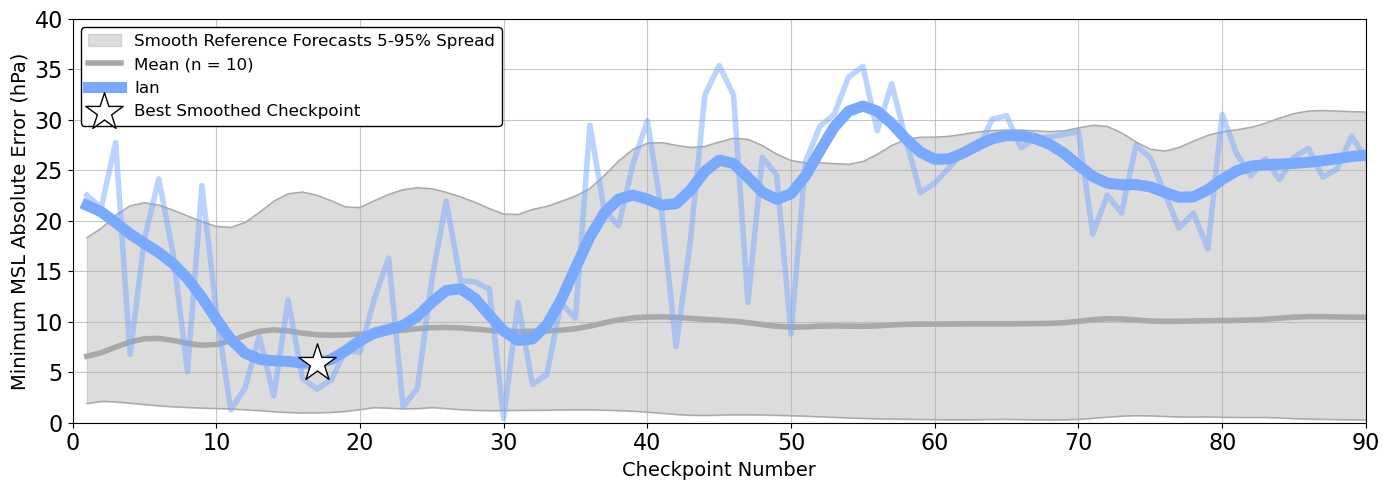

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))

reference_color = "darkgrey"
event_color = '#79a9ff'

# Calculate mean and 10th/90th percentiles for reference columns
reference_mean = reference_metrics_smooth.mean(axis=1)
reference_p10 = reference_metrics_smooth.quantile(0.05, axis=1)
reference_p90 = reference_metrics_smooth.quantile(.95, axis=1)
reference_label = f'Smooth Reference Forecasts'

# Plot the reference spread (10-90% quantile)
ax1.fill_between(metrics_df.index, reference_p10, reference_p90, color=reference_color, alpha=0.4, label=f'{reference_label} 5-95% Spread', zorder =1)

# Plot the reference mean and 10th/90th percentiles
ax1.plot(metrics_df.index, reference_mean, linestyle='-', color=reference_color, alpha=1, linewidth=4, markersize=8, label=f'Mean (n = {reference_metrics.shape[1]})')
ax1.plot(metrics_df.index, reference_p10, linestyle='-', color=reference_color, alpha=1, linewidth=1, markersize=8)
ax1.plot(metrics_df.index, reference_p90, linestyle='-', color=reference_color, alpha=1, linewidth=1, markersize=8)

# plot event and smoothed event
ax1.plot(metrics_df.index, event_metrics, linestyle='-', color= event_color, alpha=.5, linewidth=4, markersize=5)
ax1.plot(metrics_df.index, event_metrics_smooth, linestyle='-', color= event_color, alpha=1, linewidth=8, markersize=5, label=f'{event_name}')
# plot best smoothed checkpoint
ax1.scatter(min_event, event_metrics_smooth.loc[min_event], marker = "*", color='black', facecolor = "white", s=800, zorder=5, label='Best Smoothed Checkpoint')


ax1.set_xlabel('Checkpoint Number', fontsize=14)
ax1.set_xlim(0, 90)
plt.xticks(ticks=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90], fontsize=16)

ax1.set_ylabel('Minimum MSL Absolute Error (hPa)', fontsize=14)
ax1.set_ylim(0, 40)

plt.grid(True, alpha=0.7)

plt.yticks(fontsize=16)
plt.tight_layout()
legend = plt.legend(
    fontsize='large',
    edgecolor='black', 
    facecolor='white', framealpha=1)


# plt.savefig(f"figure.png", dpi=300, bbox_inches='tight')
